## Game

In [62]:
from copy import deepcopy
from collections import deque
import random
import torch
from enum import Enum

class GameElements(Enum):
    WALL = 0
    PLAYER = 1
    GOAL = 2
    BOX = 3
    FLOOR = 4
    BOX_ON_GOAL = 5
    PLAYER_ON_GOAL = 6
    BEDROCK = 7

class Game:

    def __init__(self, level_id=None, disable_prints=True, ind=0):

        # Initialize the game board as a list of lists (2D array)
        self.level_id = level_id
        self.board = Game.load_level(ind)

        # Initialize the game elements
        self.player_position = self.find_elements([GameElements.PLAYER.value, GameElements.PLAYER_ON_GOAL.value])[0]
        self.box_positions = sorted(self.find_elements([GameElements.BOX.value, GameElements.BOX_ON_GOAL.value]))
        self.goal_positions = sorted(self.find_elements([GameElements.PLAYER_ON_GOAL.value, GameElements.BOX_ON_GOAL.value, GameElements.GOAL.value]))
        self.edge_list = self.construct_edge_list(self.board)

        # Status of the game:
        self.disable_prints = disable_prints
        self.end = 0
        self.turn = 0
        self.max_number_of_turns = 100
        self.current_move = None
        self.delta_box_on_goal = 0

        # Rewards
        self.reward_win = 20
        self.reward_box_on = 5
        self.reward_box_off = -5
        self.reward_step = -1

    def convert_map_to_level(map):
          level = [[0 for _ in range(len(row))] for row in map]
          for row in range(len(map)):
            for col in range(len(map[row])):
                char = map[row][col]
                if char == "#":
                    level[row][col] = GameElements.WALL.value
                elif char == " ":
                    level[row][col] = GameElements.FLOOR.value
                elif char == "$":
                    level[row][col] = GameElements.BOX.value
                elif char == ".":
                    level[row][col] = GameElements.GOAL.value
                elif char == "@":
                    level[row][col] = GameElements.PLAYER.value
                elif char == "*":
                    level[row][col] = GameElements.BOX_ON_GOAL.value
                elif char == "+":
                    level[row][col] = GameElements.PLAYER_ON_GOAL.value
                elif char == ":":
                    level[row][col] = GameElements.BEDROCK.value
          return level

    def load_level(ind=0):
      map = ["#####",
            "#   #",
            "#.$@#",
            "#  $#",
            "## .#",
            ":####"]
      if ind == 1:
        map = ["######",
              "#    #",
              "#.$ @#",
              "#    #",
              "#  $ #",
              "## . #",
              ":#####"]
      if ind == 2:
        map = ["#######",
              "#   #.#",
              "# # # #",
              "#@# # #",
              "#$# #$#",
              "#.#   #",
              "#######"]
      if ind==3:
        map=["####::",
            "# .#::",
            "#  ###",
            "#*@  #",
            "#  $ #",
            "#  ###",
            "####::"]
      return Game.convert_map_to_level(map)



    # Main loop of the game. If the game is played via the command line interface no moves need to be passed as arguments.
    # If the game is played step by step by an agent for example, the moves need to be passed as arguments.
    def play(self, moves=None):
        self.print_board()
        if moves is None:
            while(True):
                    self.turn+=1
                    self.input()
                    self.update_positions()
                    self.update_game_status()
                    self.print_board()
        else:
            for move in moves:
                self.turn+=1
                self.current_move = move
                self.update_positions()
                self.update_game_status()
                self.print_board()
            return self.state()

    # POST: Returns a move in ['w', 'a', 's', 'd']
    def input(self):
        while(True):
            user_input = input().strip().lower()
            if user_input in ["w", "a", "s", "d"]:
                self.current_move = user_input
                return
            else:
                print("Invalid input. Please enter 'w', 'a', 's', 'd'")
                return

    # Prints the current state of the game board
    def print_board(self, board=None):
        if self.disable_prints:
            return
        if board is None:
            board = self.board

        char_mapping = {
            str(GameElements.WALL.value): '#',
            str(GameElements.FLOOR.value): " ",
            str(GameElements.BOX.value): "$",
            str(GameElements.GOAL.value): ".",
            str(GameElements.PLAYER.value): "@",
            str(GameElements.BOX_ON_GOAL.value): "*",
            str(GameElements.PLAYER_ON_GOAL.value): "+",
            str(GameElements.BEDROCK.value): ":"
        }
        for row in board:

            row  = ''.join(str(element) for element in row)
            print("".join(char_mapping[char] for char in row))

    # POST: Returns the positions of all occurrences of element on the board
    # Search starts from the top left corner of the board
    # If a list of elements is passed, the function returns the positions of all occurrences of all the elements
    def find_elements(self, element, board=None):

        if board is None:
            board = self.board
        positions = [
            [x, y]
            for x, row in enumerate(board)
            for y, char in enumerate(row)
            if (isinstance(element, list) and char in element) or char == element
        ]
        return positions

    # POST: uses bfs to return the interior of a given board.
    # For example, the interior of the following board:
    # #####..
    # #   ###
    # #.$@$.#
    # #######
    # is:
    # #####::
    # #   ###
    # #     #
    # #######
    def find_interior(self, board=None):
        if board is None:
            board = self.board
        board = deepcopy(board)
        height = len(board)
        width = max([len(board[i]) for i in range(height)])
        interior = [[GameElements.WALL.value for _ in range(width)] for _ in range(height)]

        # use breadth first search to find the interior
        queue = deque([self.player_position])
        while queue:
            x, y = queue.popleft()
            if interior[x][y] == GameElements.WALL.value:
                interior[x][y] = GameElements.FLOOR.value
                for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                    new_x, new_y = x + dx, y + dy
                    if 0 <= new_x < height and 0 <= new_y < width and board[new_x][new_y] in [GameElements.FLOOR.value, GameElements.GOAL.value, GameElements.BOX.value, GameElements.BOX_ON_GOAL.value, GameElements.PLAYER.value, GameElements.PLAYER_ON_GOAL.value]:
                        if interior[new_x][new_y] == GameElements.WALL.value:
                            queue.append((new_x, new_y))
                            board[new_x][new_y] = ';' # mark as visited

        for x in range(height):
            for y in range(width):
                if board[x][y] == GameElements.BEDROCK.value:
                    interior[x][y] = GameElements.BEDROCK.value
        return interior

    # POST: Draws the current Player and Box positions on the board
    def redraw_board(self, player_position=None, box_positions=None, board=None):
        if board is None:
            board = self.board
        if player_position is None:
            player_position = self.player_position
        if box_positions is None:
            box_positions = self.box_positions

        for goal_position in self.goal_positions:
            board[goal_position[0]][goal_position[1]] = GameElements.GOAL.value

        board[player_position[0]][player_position[1]] = GameElements.PLAYER_ON_GOAL.value if player_position in self.goal_positions else GameElements.PLAYER.value

        for box_position in box_positions:
            board[box_position[0]][box_position[1]] = GameElements.BOX_ON_GOAL.value if box_position in self.goal_positions else GameElements.BOX.value

    def update_positions(self):
        next_player_position = self.adjacent_position(self.player_position)
        next_player_obstacle = self.board[next_player_position[0]][next_player_position[1]]
        self.delta_box_on_goal = 0
        # Player runs into a wall
        if next_player_obstacle == GameElements.WALL.value:
            return
        # Player runs into a box
        elif next_player_obstacle in [GameElements.BOX.value, GameElements.BOX_ON_GOAL.value]:
            next_box_position = self.adjacent_position(next_player_position)
            next_box_obstacle = self.board[next_box_position[0]][next_box_position[1]]

            # Box can be pushed if there is floor or goal behind it
            if next_box_obstacle in [GameElements.FLOOR.value, GameElements.GOAL.value]:
                # box is on goal and pushed onto floor
                if next_player_obstacle == GameElements.BOX_ON_GOAL.value and next_box_obstacle == GameElements.FLOOR.value:
                  self.delta_box_on_goal = -1
                # box is on floor and pushed onto goal
                if next_player_obstacle == GameElements.BOX.value and next_box_obstacle == GameElements.GOAL.value:
                  self.delta_box_on_goal = 1
                box_index = self.box_positions.index(next_player_position)
                self.box_positions[box_index] = next_box_position
                self.board[self.player_position[0]][self.player_position[1]] = GameElements.FLOOR.value
                self.player_position = next_player_position

            # There is a wall or another box behind the box, so it cannot be pushed
            else:
                return
        # Next position is floor or goal
        elif next_player_obstacle in [GameElements.FLOOR.value, GameElements.GOAL.value]:
            self.board[self.player_position[0]][self.player_position[1]] = GameElements.FLOOR.value
            self.player_position = next_player_position

        else:
            print("ERROR")
            assert(0)
        self.redraw_board()

    # POST: Returns the position of the player after a move
    def adjacent_position(self, position, move=None):
        if move is None:
            move = self.current_move
        move_dict = {"w": (-1, 0), "a": (0, -1), "s": (1, 0), "d": (0, 1)}
        delta_x, delta_y = move_dict.get(move, (0, 0))
        new_position = [position[0] + delta_x, position[1] + delta_y]
        return new_position

    # POST: Updates the game status:
    # Game is won if all boxes are on goals and the number of turns is less than the maximum number of turns
    # otherwise game is lost if the number of turns is greater than the maximum number of turns
    def update_game_status(self):
        if(sorted(self.box_positions) == sorted(self.goal_positions) and self.turn <= self.max_number_of_turns):
                self.end = 1
                if not self.disable_prints:
                    print("WIN!")
        elif self.turn > self.max_number_of_turns:
            self.end = 1
            if not self.disable_prints:
                print("LOSE!")

    # POST: Returns the features of the state if action were taken, without actually changing the state of the game
    # is used for the RL agent to compute the value of the next state
    def step(self, action):
        board = deepcopy(self.board)
        player_position = deepcopy(self.player_position)
        box_positions = deepcopy(self.box_positions)

        next_player_position = self.adjacent_position(player_position, move=action)
        next_player_obstacle = board[next_player_position[0]][next_player_position[1]]

        # delta of boxes in current turn. 0 if no box moved on or off a goal, 1 if a box moved on goal, -1 if box moved off goal
        delta_box_on_goal = 0

        # Player runs into a wall
        if next_player_obstacle == GameElements.WALL.value:
            return
        # Player runs into a box
        elif next_player_obstacle in [GameElements.BOX.value, GameElements.BOX_ON_GOAL.value]:
            next_box_position = self.adjacent_position(next_player_position, move=action)
            next_box_obstacle = board[next_box_position[0]][next_box_position[1]]

            # Box can be pushed if there is floor or goal behind it
            if next_box_obstacle in [GameElements.FLOOR.value, GameElements.GOAL.value]:
              # box is goal and is pushed onto floor
              if next_player_obstacle == GameElements.BOX_ON_GOAL.value and next_box_obstacle == GameElements.FLOOR.value:
                delta_box_on_goal = -1
              # box is on floor and is pushed onto goal
              if next_player_obstacle == GameElements.BOX.value and next_box_obstacle == GameElements.GOAL.value:
                delta_box_on_goal = 1
              box_index = box_positions.index(next_player_position)
              box_positions[box_index] = next_box_position
              board[player_position[0]][player_position[1]] = GameElements.FLOOR.value
              player_position = next_player_position

            # There is a wall or another box behind the box, so it cannot be pushed
            else:
                return

        elif next_player_obstacle in [GameElements.FLOOR.value, GameElements.GOAL.value]:
            board[player_position[0]][player_position[1]] = GameElements.FLOOR.value
            player_position = next_player_position

        else:
            print("ERROR")
            assert(0)
        self.redraw_board(board=board, player_position=player_position, box_positions=box_positions)
        targets = self.targets(box_positions=box_positions)
        return self.embed(board), self.reward(board, turn=self.turn+1, delta=delta_box_on_goal), 1 if targets == 1 or self.turn + 1> self.max_number_of_turns else 0

    # POST: Returns a dictionary that contains the distances between the start and the end positions, where the keys are the end positions and the values the distances
    def bfs(self, start, end, board):
        distance = {}
        reached_goals = set()
        queue = deque([start])
        height = len(board)
        width = max(len(row) for row in board)
        visited = [[False for _ in range(width)] for _ in range(height)]
        visited[start[0]][start[1]] = True
        step = 0
        while queue:
            for _ in range(len(queue)):
                x, y = queue.popleft()
                if [x, y] in end:
                    reached_goals.add((x, y))
                    distance[(x, y)] = step
                    if len(reached_goals) == len(end):
                        return distance
                for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                    new_x, new_y = x + dx, y + dy
                    if 0 <= new_x < height and 0 <= new_y < width and not visited[new_x][new_y]:
                        if board[new_x][new_y] in [GameElements.FLOOR.value, GameElements.GOAL.value, GameElements.BOX.value, GameElements.BOX_ON_GOAL.value, GameElements.PLAYER.value, GameElements.PLAYER_ON_GOAL.value]:
                            queue.append((new_x, new_y))
                            visited[new_x][new_y] = True
            step += 1
        return distance

    def legal_moves(self):
        legal_moves = {"w": True, "a": True, "s": True, "d": True}
        for move in legal_moves:
            next_player_position = self.adjacent_position(self.player_position, move=move)
            next_player_obstacle = self.board[next_player_position[0]][next_player_position[1]]
            if next_player_obstacle == GameElements.WALL.value:
                legal_moves[move] = False
            if next_player_obstacle in [GameElements.BOX.value, GameElements.BOX_ON_GOAL.value]:
                next_box_position = self.adjacent_position(next_player_position, move=move)
                next_box_obstacle = self.board[next_box_position[0]][next_box_position[1]]
                if next_box_obstacle in [GameElements.WALL.value, GameElements.BOX.value, GameElements.BOX_ON_GOAL.value]:
                    legal_moves[move] = False
        return [key for key, value in legal_moves.items() if value is True]

    def targets(self, box_positions):
        return len(set(map(tuple, box_positions)).intersection(set(map(tuple,self.goal_positions))))/len(self.box_positions)

    # POST: returns the state of the game
    def state(self):
        return self.embed(self.board), self.reward(self.board, self.turn, self.delta_box_on_goal), self.end

    def reward(self, board, turn, delta):

        # game won
        if len(self.find_elements([GameElements.BOX_ON_GOAL.value], board)) == len(self.goal_positions) and turn < self.max_number_of_turns:
            return self.reward_win
        # box moved on a target
        if delta == 1:
          return self.reward_box_on
        # box moved off target
        if delta == -1:
          return self.reward_box_off
        else:
            return self.reward_step


    # Nodes of the graph include all game elements exept WALLs and BEDROCK
    def embed(self, board):
        height = len(board)
        width = len(board[0])
        nodes = []
        for i in range(height):
            for j in range(width):
                element = board[i][j]
                if element not in [GameElements.WALL.value, GameElements.BEDROCK.value]:
                  nodes.append(torch.tensor([element]))  # Append tensor to the list

        nodes = torch.cat(nodes, dim=0)
        return nodes

    def construct_edge_list(self, board):
        height = len(board)
        width = len(board[0])
        node_indices = {}
        ind = 0
        edge_list = [[],[]]
        for i in range(height):
            for j in range(width):
                if not board[i][j] in [GameElements.WALL.value, GameElements.BEDROCK.value]:
                    node_indices[(i,j)] = ind
                    ind +=1
        for i in range(height):
            for j in range(width):
                if board[i][j] not in [GameElements.WALL.value, GameElements.BEDROCK.value]:
                    for dx, dy in [(0,1), (1,0), (0,-1), (-1,0)]:
                        x = i + dx
                        y = j + dy
                        if (0 <= x < height) and (0 <= y < width):
                            if board[x][y] not in [GameElements.WALL.value, GameElements.BEDROCK.value]:
                                edge_list[0].append(node_indices[(i,j)])
                                edge_list[1].append(node_indices[(x,y)])

        return torch.tensor(edge_list, dtype=torch.int64).view((2, -1))

In [67]:
test = Game(disable_prints=False, ind = 1)
test.print_board()
print(test.embed(test.board))
print(test.state())

######
#    #
#.$ @#
#    #
#  $ #
## . #
:#####
tensor([4, 4, 4, 4, 2, 3, 4, 1, 4, 4, 4, 4, 4, 4, 3, 4, 4, 2, 4])
(tensor([4, 4, 4, 4, 2, 3, 4, 1, 4, 4, 4, 4, 4, 4, 3, 4, 4, 2, 4]), -1, 0)


## Agent

In [68]:
!pip install torch_geometric
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
from torch_geometric.nn import TopKPooling
import torch.nn.functional as F
from torch.nn import Linear

import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
import random
import importlib
from copy import deepcopy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv, TransformerConv, global_max_pool
Conv = TransformerConv

class GraphNet(torch.nn.Module):
    def __init__(self, init_value, layers, hidden_dim):
        super(GraphNet, self).__init__()
        self.num_embeddings = 8  # 8 Game elements (not including walls and bedrock)
        self.embedding_dim = 24
        self.in_channels = self.embedding_dim
        self.hidden_channels = hidden_dim
        self.out_channels = 1
        self.embedding_layer = nn.Embedding(self.num_embeddings, self.embedding_dim)

        self.conv = nn.ModuleList()
        self.conv.append(Conv(self.in_channels, self.hidden_channels))
        for layer in range(layers - 1):
            self.conv.append(Conv(self.hidden_channels, self.hidden_channels))

        self.lin1 = nn.Linear(self.hidden_channels, self.hidden_channels)
        self.lin2 = nn.Linear(self.hidden_channels, self.out_channels)

        # Optimistic Initialization
        self.optimistic_init(self.lin2, init_value=init_value)

        # Dropout
        self.dropout = nn.Dropout(p=0.2)

    def optimistic_init(self, layer, init_value):
      if layer.bias is not None:
        nn.init.constant_(layer.bias, init_value)

    def forward(self, data):
        x, edge_list = data.x, data.edge_list
        node_indices = x.long()
        x = self.embedding_layer(node_indices)
        for conv in self.conv:
            x = F.relu(conv(x, edge_list))
            x = self.dropout(x)
        x = global_max_pool(x, data.batch)
        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        x = self.lin2(x)
        return x


In [105]:
class ForwardAgent():
  def __init__(self, lr=0.01, alpha=0.3, gamma=0.8, eps=0.2, init_value=5, layers=3, hidden_dim=12):
    self.value_network = GraphNet(init_value=init_value, layers=layers, hidden_dim=hidden_dim)
    self.optimizer = optim.Adam(self.value_network.parameters(), lr=lr)
    self.loss = nn.MSELoss()
    self.alpha = alpha
    self.gamma = gamma
    self.eps = eps
    print(f"gamma: {gamma}, eps: {eps}, alpha: {alpha}, lr: {lr}, init_value: {init_value}, layers: {layers}, hidden_dim: {hidden_dim}")

  def policy(self, env):
    self.value_network.eval()
    legal_moves = env.legal_moves()
    assert len(legal_moves), "agent is stuck"
    value_moves = []
    for char in legal_moves:
        nodes, reward, done = env.step(char)
        data = Data(x=nodes, edge_list=env.edge_list)
        value_moves.append([char, nodes, reward, done, self.value_network(data)])
    return max(value_moves, key=lambda x:x[-1])

  def random_policy(self, env):
    legal_moves = env.legal_moves()
    if len(legal_moves)==0:
      return None
    else:
      return random.choice(legal_moves)

  def random_baseline(self, number_of_episodes, ind, plot=True):
    wins=[0 for i in range(number_of_episodes)]
    moves=[]
    for episode in tqdm(range(number_of_episodes)):
        # create new game instance
        env = Game(disable_prints=True, ind=ind)
        if episode % 100 == 0 or episode == number_of_episodes-1:
            moves.append(env.player_position)
        nodes, reward, done = env.state()
        while not done:
          action = self.random_policy(env)
          if episode % 100 == 0:
            moves.append(action)
          if action != None:
            nodes, reward, done = env.play(action)
            wins[episode] = wins[episode] + (1 if reward == env.reward_win else 0)
          else:
            done = 1
    if plot:
      plt.plot([sum(wins[:i])/number_of_episodes for i in range(number_of_episodes)], label="forward random policy")
      plt.legend()
    print(f"forward agent random policy solved: {sum(wins)/number_of_episodes}, {sum(wins)}/{number_of_episodes}")

  def train(self, number_of_episodes, ind, plot=True):
      wins = [0 for _ in range(number_of_episodes)]
      moves = []
      for episode in tqdm(range(number_of_episodes)):

        # Initialize the game
        env = Game(disable_prints=True, ind=ind)
        if episode % 100 == 0 or episode == number_of_episodes-1:
            moves.append(env.player_position)

        nodes, reward, done = env.state()
        while not done:
          # Choose action
          action, next_nodes, reward, done = self.choose_action(env)
          # TD(0) update
          self.update_agent(nodes,env.edge_list, next_nodes, reward, done)

          # Update game state if action is chosen
          if action is not None:
            nodes, reward, done = env.play(action)
            assert torch.equal(next_nodes, nodes), "nodes mismatch after action"

          wins[episode] = wins[episode] + (1 if reward ==  env.reward_win else 0)
          node = next_nodes

          if episode % 100 == 0 or episode == number_of_episodes-1:
            moves.append(action)

      if plot:
          #plt.plot([sum(wins[:i])/number_of_episodes for i in range(number_of_episodes)], label="forward greedy policy")
          plt.scatter([i for i in range(len(wins))], wins, label="forward greedy policy")
          plt.legend()
          file_path = "forward_run.json"
          json_data = json.dumps(moves)
          with open(file_path, "w") as file:
              file.write(json_data)

      print(f"forward agent greedy policy solved: {sum(wins)/number_of_episodes}, {sum(wins)}/{number_of_episodes}")
      return wins, moves

  def choose_action(self, env):
    action, next_nodes, next_reward, next_done = None, None, None, None
    legal_moves = env.legal_moves()
    # agent is stuck and can't move
    if len(legal_moves) == 0:
      next_nodes, next_reward, next_done = env.state()
      next_done=1
    # exploration
    elif np.random.rand() < self.eps:
      action = random.choice(legal_moves)
      next_nodes, next_reward, next_done = env.step(action)
    # exploitation
    else:
      [action, next_nodes, next_reward, next_done, _] = self.policy(env)
    return action, next_nodes, next_reward, next_done

  def update_agent(self, nodes, edge_list, next_nodes, reward, done):

    data = Data(x=nodes, edge_list=edge_list)
    next_data = Data(x=next_nodes, edge_list=edge_list)

    value = self.value_network(data)
    next_value = self.value_network(next_data).detach()

    # TD(0) update: V(s)←V(s)+α(R+γV(s')−V(s))
    target = value + self.alpha * (reward + self.gamma * next_value * (1 - done) - value) # using detach here to exclude prediction from computation graph as is standard in TD(0)

    # calculate loss
    loss = self.loss(value,target)
    # optimize
    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

  def inference(self, ind):

    # Initialize the game
    env = Game(disable_prints=True, ind=ind)
    moves = {
        "w": 0,
        "a": 0,
        "s": 0,
        "d": 0
    }

    nodes, reward, done = env.state()
    while not done:
      # Choose action
      action, next_nodes, next_reward, next_done = None, None, None, None
      legal_moves = env.legal_moves()
      # agent is stuck and can't move
      if len(legal_moves) == 0:
        next_nodes, next_reward, next_done = env.state()
        next_done=1
      # exploration
      elif np.random.rand() < self.eps:
        action = random.choice(legal_moves)
        next_nodes, next_reward, next_done = env.step(action)
      # exploitation
      else:
        self.value_network.eval()
        value_moves = []
        for char in legal_moves:
            nodes, reward, done = env.step(char)
            data = Data(x=nodes, edge_list=env.edge_list)
            est_value = self.value_network(data)
            value_moves.append([char, nodes, reward, done, est_value])
            print(f"move: {char}, with est. value {est_value.item():.9f}")
        [action, next_nodes, next_reward, next_done, _] = max(value_moves, key=lambda x:x[-1])

      # TD(0) update
      self.update_agent(nodes,env.edge_list, next_nodes, reward, done)

      # Update game state if action is chosen
      if action is not None:
        # print game state
        print("---")
        env.disable_prints=False
        env.print_board()
        env.disable_prints=True
        print(f"action {action}")
        moves[action] += 1
        nodes, reward, done = env.play(action)
        assert torch.equal(next_nodes, nodes), "nodes mismatch after action"
      node = next_nodes
    print(moves)

gamma: 0.8, eps: 0.2, alpha: 0.3, lr: 0.01, init_value: 5, layers: 8, hidden_dim: 35


100%|██████████| 50/50 [00:00<00:00, 51.41it/s]


forward agent random policy solved: 0.0, 0/50


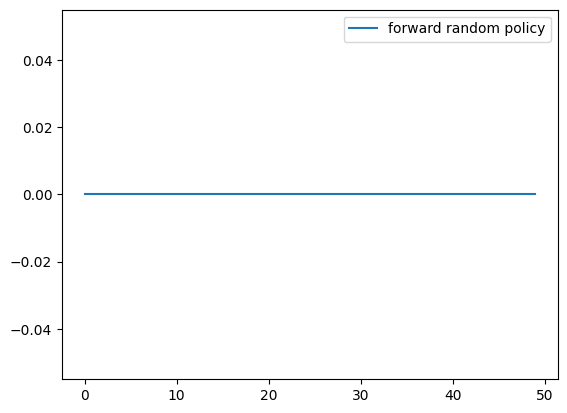

In [82]:
forwardagent = ForwardAgent(layers=8, hidden_dim=35)
forwardagent.random_baseline(number_of_episodes=50, ind=3)

gamma: 0.8, eps: 0.2, alpha: 0.3, lr: 0.01, init_value: 5, layers: 8, hidden_dim: 256
iteration: 0


100%|██████████| 10/10 [01:17<00:00,  7.76s/it]


forward agent greedy policy solved: 0.0, 0/10
move: w, with est. value -4.315990925
move: s, with est. value -4.315990925
move: d, with est. value -4.315990925
---
####::
# .#::
#  ###
#*@  #
#  $ #
#  ###
####::
action w
move: w, with est. value -3.810422897
move: a, with est. value -3.810422897
move: s, with est. value -3.810422897
---
####::
# .#::
# @###
#*   #
#  $ #
#  ###
####::
action w
move: a, with est. value -3.405383110
move: s, with est. value -3.405383110
---
####::
# +#::
#  ###
#*   #
#  $ #
#  ###
####::
action a
move: s, with est. value -3.092668056
move: d, with est. value -3.092668056
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
move: w, with est. value -2.863339424
move: s, with est. value -2.863339424
move: d, with est. value -2.863339424
---
####::
# .#::
#@ ###
#*   #
#  $ #
#  ###
####::
action w
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action d
move: a, with est. value -2.619789124
move: s, with est. value -2.619789124
---
####::
#

100%|██████████| 10/10 [01:38<00:00,  9.88s/it]


forward agent greedy policy solved: 0.0, 0/10
move: w, with est. value -4.611281395
move: s, with est. value -4.611281395
move: d, with est. value -4.611281395
---
####::
# .#::
#  ###
#*@  #
#  $ #
#  ###
####::
action w
move: w, with est. value -4.266983032
move: a, with est. value -4.266983032
move: s, with est. value -4.266983032
---
####::
# .#::
# @###
#*   #
#  $ #
#  ###
####::
action w
move: a, with est. value -3.979136467
move: s, with est. value -3.979136467
---
####::
# +#::
#  ###
#*   #
#  $ #
#  ###
####::
action a
move: s, with est. value -3.744941235
move: d, with est. value -3.744941235
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
move: w, with est. value -3.562370300
move: s, with est. value -3.562370300
move: d, with est. value -3.562370300
---
####::
# .#::
#@ ###
#*   #
#  $ #
#  ###
####::
action w
move: s, with est. value -3.422854900
move: d, with est. value -3.422854900
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
move: w, wit

...

forward agent greedy policy solved: 0.0, 0/10
move: w, with est. value -4.592656612
move: s, with est. value -4.592656612
move: d, with est. value -4.592656612
---
####::
# .#::
#  ###
#*@  #
#  $ #
#  ###
####::
action w
move: w, with est. value -4.256926060
move: a, with est. value -4.256926060
move: s, with est. value -4.256926060
---
####::
# .#::
# @###
#*   #
#  $ #
#  ###
####::
action w
---
####::
# +#::
#  ###
#*   #
#  $ #
#  ###
####::
action a
move: s, with est. value -3.746279716
move: d, with est. value -3.746279716
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
move: w, with est. value -3.563498020
move: s, with est. value -3.563498020
move: d, with est. value -3.563498020
---
####::
# .#::
#@ ###
#*   #
#  $ #
#  ###
####::
action w
move: s, with est. value -3.423685551
move: d, with est. value -3.423685551
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
move: w, with est. value -3.322977543
move: s, with est. value -3.322977543
move: d, wit

100%|██████████| 10/10 [01:30<00:00,  9.07s/it]


forward agent greedy policy solved: 0.0, 0/10
move: w, with est. value -4.604958057
move: s, with est. value -4.604958057
move: d, with est. value -4.604958057
---
####::
# .#::
#  ###
#*@  #
#  $ #
#  ###
####::
action w
move: w, with est. value -4.298402786
move: a, with est. value -4.298402786
move: s, with est. value -4.298402786
---
####::
# .#::
# @###
#*   #
#  $ #
#  ###
####::
action w
move: a, with est. value -4.041084290
move: s, with est. value -4.041084290
---
####::
# +#::
#  ###
#*   #
#  $ #
#  ###
####::
action a
move: s, with est. value -3.829765320
move: d, with est. value -3.829765320
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
move: w, with est. value -3.660974026
move: s, with est. value -3.660974026
move: d, with est. value -3.660974026
---
####::
# .#::
#@ ###
#*   #
#  $ #
#  ###
####::
action w
move: s, with est. value -3.531230450
move: d, with est. value -3.531230450
---
####::
#@.#::
#  ###
#*   #
#  $ #
#  ###
####::
action s
---
####::
#

 40%|████      | 4/10 [00:41<01:02, 10.33s/it]


KeyboardInterrupt: 

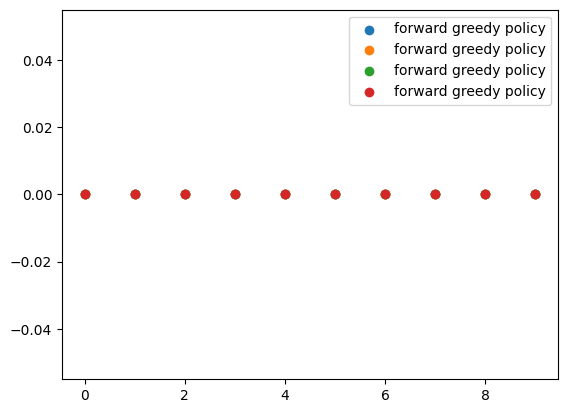

In [106]:
torch.manual_seed(40)
random.seed(40)
np.random.seed(40)

forwardagent = ForwardAgent(layers=8, hidden_dim=256)
for i in range(5):
  print(f"iteration: {i}")
  wins, moves = forwardagent.train(number_of_episodes=10, ind=2)
  forwardagent.inference(ind=3)

gamma: 0.8, eps: 0.2, alpha: 0.3, lr: 0.01, init_value: 100, layers: 3, hidden_dim: 12
---
######
#    #
#.$ @#
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[99.9704]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[99.9702]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[99.9696]], grad_fn=<AddmmBackward0>)
----
greedy move: w
---
######
#   @#
#.$  #
#    #
#  $ #
## . #
:#####
action a, with estim. value: tensor([[99.9704]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[99.9704]], grad_fn=<AddmmBackward0>)
----
greedy move: a
---
######
#  @ #
#.$  #
#    #
#  $ #
## . #
:#####
action a, with estim. value: tensor([[99.9718]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[99.9702]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[99.9704]], grad_fn=<AddmmBackward0>)
----
greedy move: a
---
######
# @  #
#.$  #
#    #
#  $ #
## . #
:#####
action a, with estim. value: tensor([[99.

100%|██████████| 50/50 [00:50<00:00,  1.00s/it]


forward agent greedy policy solved: 0.34, 17/50
---
######
#    #
#.$ @#
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[57.2253]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[58.0218]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[57.2253]], grad_fn=<AddmmBackward0>)
----
greedy move: a
random move: w
---
######
#  @ #
#.$  #
#    #
#  $ #
## . #
:#####
action a, with estim. value: tensor([[57.5879]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[58.0218]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[57.2253]], grad_fn=<AddmmBackward0>)
----
greedy move: s
---
######
#    #
#.$@ #
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[57.2668]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[63.3377]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[57.2779]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[57.2349]], grad_fn=<Addmm

100%|██████████| 50/50 [00:29<00:00,  1.70it/s]


forward agent greedy policy solved: 0.72, 36/50
---
######
#    #
#.$ @#
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[-5.0278]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[-1.5251]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[-5.0278]], grad_fn=<AddmmBackward0>)
----
greedy move: a
random move: s
---
######
#    #
#.$  #
#  @ #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[-1.5251]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[-1.7896]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[-4.8827]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[-5.0278]], grad_fn=<AddmmBackward0>)
----
greedy move: w
---
######
#    #
#.$@ #
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[-5.4977]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[-0.9619]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[-5.3667]], grad_fn=<Addmm

100%|██████████| 50/50 [00:22<00:00,  2.20it/s]


forward agent greedy policy solved: 0.84, 42/50
---
######
#    #
#.$ @#
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[37.0047]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[51.0795]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[37.0047]], grad_fn=<AddmmBackward0>)
----
greedy move: a
---
######
#    #
#.$@ #
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[40.1005]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[51.1119]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[38.4128]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[37.0476]], grad_fn=<AddmmBackward0>)
----
greedy move: a
random move: d
---
######
#    #
#* @ #
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[51.2894]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[51.1119]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[82.7948]], grad_fn=<Addmm

100%|██████████| 50/50 [00:13<00:00,  3.68it/s]


forward agent greedy policy solved: 0.88, 44/50
---
######
#    #
#.$ @#
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[43.5908]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[49.4685]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[43.5908]], grad_fn=<AddmmBackward0>)
----
greedy move: a
---
######
#    #
#.$@ #
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[44.5448]], grad_fn=<AddmmBackward0>)
action a, with estim. value: tensor([[49.0587]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[44.4679]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[43.6501]], grad_fn=<AddmmBackward0>)
----
greedy move: a
---
######
#    #
#*@  #
#    #
#  $ #
## . #
:#####
action w, with estim. value: tensor([[49.1637]], grad_fn=<AddmmBackward0>)
action s, with estim. value: tensor([[50.5146]], grad_fn=<AddmmBackward0>)
action d, with estim. value: tensor([[49.8598]], grad_fn=<AddmmBackward0>)
---

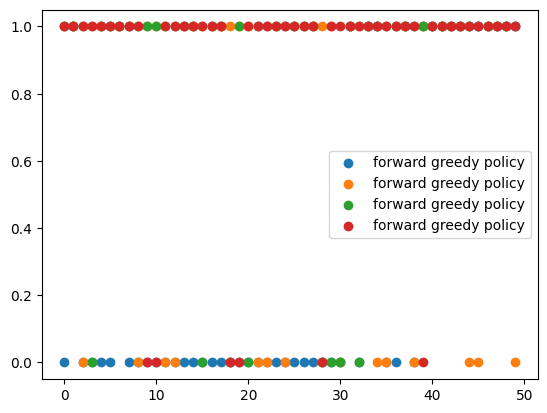

In [85]:
forwardagent = ForwardAgent()
forwardagent.inference(ind=1)

for _ in range(4):
  forwardagent.train(number_of_episodes=50, ind=1)
  forwardagent.inference(ind=1)

todo:
check init
add random offset to get out of stable states